<a href="https://colab.research.google.com/github/aviksarkar0204-stack/TruthScanAI/blob/main/notebooks/FakeGuard_Retrain_ClassicML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import time
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

In [46]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to C:\Users\Arup
[nltk_data]     sarkar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Arup
[nltk_data]     sarkar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [47]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to C:\Users\Arup
[nltk_data]     sarkar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [48]:
df_fake = pd.read_csv("C:/Users/Arup sarkar/Documents/PythonFile/FakeNewsDetection/Fake.csv")
df_true = pd.read_csv("C:/Users/Arup sarkar/Documents/PythonFile/FakeNewsDetection/True.csv")
df_WEL = pd.read_csv("C:/Users/Arup sarkar/Documents/PythonFile/FakeNewsDetection/WELFake_Dataset.csv")

In [49]:
df_fake

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"
...,...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016"
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016"
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016"
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016"


In [50]:
df_true

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"
...,...,...,...,...
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017"
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017"
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017"
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017"


In [51]:
df_WEL

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1
...,...,...,...,...
72129,72129,Russians steal research on Trump in hack of U....,WASHINGTON (Reuters) - Hackers believed to be ...,0
72130,72130,WATCH: Giuliani Demands That Democrats Apolog...,"You know, because in fantasyland Republicans n...",1
72131,72131,Migrants Refuse To Leave Train At Refugee Camp...,Migrants Refuse To Leave Train At Refugee Camp...,0
72132,72132,Trump tussle gives unpopular Mexican leader mu...,MEXICO CITY (Reuters) - Donald Trump’s combati...,0


In [52]:
df_true['label'] = 1
df_fake['label'] = 0

In [53]:
df_main1 = pd.concat([df_true, df_fake], axis=0)
df_main1 = df_main1.sample(frac=1,random_state=42).reset_index(drop=True)

In [54]:
df_main1 = df_main1.drop(columns = ["subject", "date"])

In [55]:
df_main1

,title,text,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",0
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,0
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,0
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,1
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,0
...,...,...,...
44893,Nigeria says U.S. agrees delayed $593 million ...,ABUJA (Reuters) - The United States has formal...,1
44894,Boiler Room #62 – Fatal Illusions,Tune in to the Alternate Current Radio Network...,0
44895,ATHEISTS SUE GOVERNOR OF TEXAS Over Display on...,I m convinced the Freedom From Religion group...,0
44896,Republican tax plan would deal financial hit t...,WASHINGTON (Reuters) - The Republican tax plan...,1


In [56]:
df_WEL = df_WEL.drop(columns = ["Unnamed: 0"])

In [57]:
df_WEL

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1
...,...,...,...
72129,Russians steal research on Trump in hack of U....,WASHINGTON (Reuters) - Hackers believed to be ...,0
72130,WATCH: Giuliani Demands That Democrats Apolog...,"You know, because in fantasyland Republicans n...",1
72131,Migrants Refuse To Leave Train At Refugee Camp...,Migrants Refuse To Leave Train At Refugee Camp...,0
72132,Trump tussle gives unpopular Mexican leader mu...,MEXICO CITY (Reuters) - Donald Trump’s combati...,0


In [58]:
df_WEL = df_WEL.dropna()

In [59]:
df_main = pd.concat([df_WEL, df_main1], axis=0, ignore_index=True)
df_main = df_main.sample(frac=1, random_state=42).reset_index(drop=True)

Let's check the first few rows and the shape of the new `df_main` DataFrame.

In [60]:
df_main

,title,text,label
0,BREAKING: FELON WEARING BLACK LIVES MATTER T-S...,Obama s war against cops and white people in f...,0
1,Eurogroup head Dijsselbloem to leave Dutch pol...,AMSTERDAM (Reuters) - Outgoing Dutch Finance M...,0
2,"Trump growing frustrated with China, weighs tr...",WASHINGTON (Reuters) - President Donald Trump ...,1
3,Trump Finally Outspends Hillary On TV Spots,"WATCH: UK Reporter RIPS CNN, Calls Them “Clint...",1
4,Exclusive: Germany wants more EU sanctions on ...,BRUSSELS (Reuters) - Germany is urging the Eur...,1
...,...,...,...
116430,STUNNING GRAPHIC Of Obama’s Legacy That Every ...,The Democrats doubled down on moving to the le...,0
116431,"Trump says open to bilateral Canada, Mexico pa...",WASHINGTON (Reuters) - U.S. President Donald T...,1
116432,"Blast in Turkish textile factory kills five, w...",ANKARA (Reuters) - An explosion at a textile f...,1
116433,"Orlando Gunman Was Shot at Least 8 Times, Auto...",The authorities in Florida said Friday that Om...,0


In [61]:
df_main.to_csv("MainOne.csv",sep=",")

Text(0.5, 1.0, 'Count Labels')

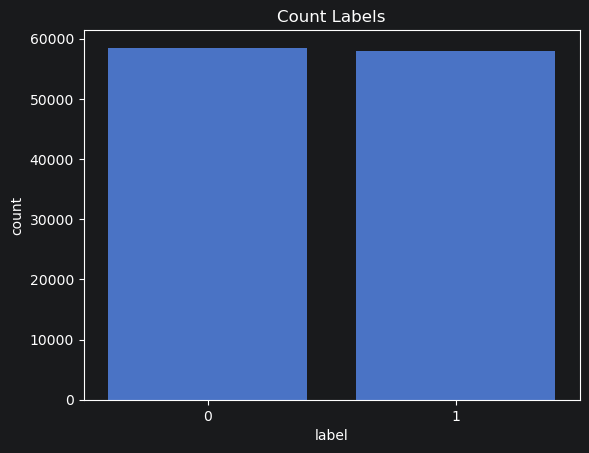

In [62]:
sns.countplot(x='label',data=df_main)
plt.title("Count Labels")

In [63]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116435 entries, 0 to 116434
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   title   116435 non-null  object
 1   text    116435 non-null  object
 2   label   116435 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 2.7+ MB


In [64]:
label_counts = df_main['label'].value_counts()
print("Count of 0 and 1 values in 'label' column:")
print(label_counts)

Count of 0 and 1 values in 'label' column:
label
0    58509
1    57926
Name: count, dtype: int64


In [65]:
def to_lower(dataframe,column):
    dataframe[column] = dataframe[column].str.lower()
    return dataframe

def remove_html(dataframe, column):
    dataframe[column] = dataframe[column].str.replace(r"<.*?>", " ", regex=True)
    return dataframe

def remove_punctuation(dataframe, column):
    dataframe[column] = dataframe[column].apply(lambda x: re.sub('[^a-zA-Z]', ' ', x))
    return dataframe

def tokenization(dataframe,column):
    dataframe[column] = dataframe[column].apply(lambda x: word_tokenize(x))
    return dataframe

def remove_stopwords(dataframe,column):
    stop_words = stopwords.words('english')
    dataframe[column] = dataframe[column].apply(lambda x:[word for word in x if word not in stop_words])
    return dataframe

def steming(dataframe,column):
    porter = PorterStemmer()
    dataframe[column] = dataframe[column].apply(lambda x: [porter.stem(word) for word in x])
    return dataframe

def list_to_string(dataframe,column):
    dataframe[column] = dataframe[column].apply(lambda x: " ".join(x))
    return dataframe

In [66]:
function_pipeline = {
    "to_lower": to_lower,
    "remove_html": remove_html,
    "remove_punctuation": remove_punctuation,
    "tokenization": tokenization,
    "remove_stopwords": remove_stopwords,
    "steming": steming,
    "list_to_string": list_to_string
}

In [67]:
df_main['content'] = df_main['title'] + ' ' + df_main['text']

In [68]:
df_main.drop(['title', 'text'], axis=1, inplace=True)

In [69]:
df_main

,label,content
0,0,BREAKING: FELON WEARING BLACK LIVES MATTER T-S...
1,0,Eurogroup head Dijsselbloem to leave Dutch pol...
2,1,"Trump growing frustrated with China, weighs tr..."
3,1,Trump Finally Outspends Hillary On TV Spots WA...
4,1,Exclusive: Germany wants more EU sanctions on ...
...,...,...
116430,0,STUNNING GRAPHIC Of Obama’s Legacy That Every ...
116431,1,"Trump says open to bilateral Canada, Mexico pa..."
116432,1,"Blast in Turkish textile factory kills five, w..."
116433,0,"Orlando Gunman Was Shot at Least 8 Times, Auto..."


In [70]:
dataframe = df_main

for name,func in function_pipeline.items():
    print(f"Applying {name} function")
    startTime = time.time()
    dataframe = func(dataframe, "content")
    endTime = time.time()
    print(f"Time taken to apply {name} function: {endTime - startTime:.2f} seconds")

Applying to_lower function
Time taken to apply to_lower function: 0.98 seconds
Applying remove_html function
Time taken to apply remove_html function: 0.16 seconds
Applying remove_punctuation function
Time taken to apply remove_punctuation function: 8.71 seconds
Applying tokenization function
Time taken to apply tokenization function: 106.61 seconds
Applying remove_stopwords function
Time taken to apply remove_stopwords function: 85.96 seconds
Applying steming function
Time taken to apply steming function: 433.13 seconds
Applying list_to_string function
Time taken to apply list_to_string function: 8.42 seconds


In [71]:
X = df_main["content"]
y = df_main["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [72]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC()
}

for name, model in models.items():
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000, stop_words='english', ngram_range=(1,2))),
        ('clf', model)
    ])
    print("====================================")
    print(f"Training {name} model...")
    start_time = time.time()
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    end_time = time.time()
    duration = end_time - start_time

    print(f"{name}: Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | Duration={duration:.2f}s")
    print(f"Confusion Matrix:\n{cm}")
    print("=====================================")

Training Logistic Regression model...
Logistic Regression: Acc=0.5278 | Prec=0.5278 | Rec=0.5278 | F1=0.5278 | Duration=103.94s
Confusion Matrix:
[[6182 5534]
 [5463 6108]]
Training Naive Bayes model...
Naive Bayes: Acc=0.5638 | Prec=0.5639 | Rec=0.5638 | F1=0.5633 | Duration=75.59s
Confusion Matrix:
[[7011 4705]
 [5452 6119]]
Training SVM model...
SVM: Acc=0.4914 | Prec=0.4914 | Rec=0.4914 | F1=0.4914 | Duration=63.44s
Confusion Matrix:
[[5809 5907]
 [5937 5634]]


In [73]:
print("ISOT label distribution:")
print(df_main1['label'].value_counts())

print("\nWELFake label distribution:")
print(df_WEL['label'].value_counts())

print("\nCombined label distribution:")
print(df_main['label'].value_counts())

# Check a few WELFake samples
print("\nWELFake sample (label=0):")
print(df_WEL[df_WEL['label']==0]['title'].head(3))

print("\nWELFake sample (label=1):")
print(df_WEL[df_WEL['label']==1]['title'].head(3))

ISOT label distribution:
label
0    23481
1    21417
Name: count, dtype: int64

WELFake label distribution:
label
1    36509
0    35028
Name: count, dtype: int64

Combined label distribution:
label
0    58509
1    57926
Name: count, dtype: int64

WELFake sample (label=0):
3     Bobby Jindal, raised Hindu, uses story of Chri...
11    May Brexit offer would hurt, cost EU citizens ...
12    Schumer calls on Trump to appoint official to ...
Name: title, dtype: object

WELFake sample (label=1):
0    LAW ENFORCEMENT ON HIGH ALERT Following Threat...
2    UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...
4    SATAN 2: Russia unvelis an image of its terrif...
Name: title, dtype: object


In [74]:
df_WEL['label'] = df_WEL['label'].map({0: 1, 1: 0})

C:\Users\Arup sarkar\AppData\Local\Temp\ipykernel_32980\4279703299.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_WEL['label'] = df_WEL['label'].map({0: 1, 1: 0})


In [75]:
print(df_WEL[df_WEL['label']==1]['title'].head(3))  # should now show real news
print(df_WEL[df_WEL['label']==0]['title'].head(3))  # should now show fake news

3     Bobby Jindal, raised Hindu, uses story of Chri...
11    May Brexit offer would hurt, cost EU citizens ...
12    Schumer calls on Trump to appoint official to ...
Name: title, dtype: object
0    LAW ENFORCEMENT ON HIGH ALERT Following Threat...
2    UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...
4    SATAN 2: Russia unvelis an image of its terrif...
Name: title, dtype: object


In [76]:
df_main_final = pd.concat([df_WEL, df_main1], axis=0, ignore_index=True)
df_main_final = df_main_final.sample(frac=1, random_state=42).reset_index(drop=True)

In [77]:
df_main_final.to_csv("MainTwo.csv",sep=",")

In [78]:
df_main_final['content'] = df_main_final['title'] + ' ' + df_main_final['text']
df_main_final.drop(columns = ['title', 'text'], inplace=True)

In [79]:
dataframe = df_main_final

for name,func in function_pipeline.items():
    print(f"Applying {name} function")
    startTime = time.time()
    dataframe = func(dataframe, "content")
    endTime = time.time()
    print(f"Time taken to apply {name} function: {endTime - startTime:.2f} seconds")

Applying to_lower function
Time taken to apply to_lower function: 1.11 seconds
Applying remove_html function
Time taken to apply remove_html function: 0.17 seconds
Applying remove_punctuation function
Time taken to apply remove_punctuation function: 11.17 seconds
Applying tokenization function
Time taken to apply tokenization function: 121.53 seconds
Applying remove_stopwords function
Time taken to apply remove_stopwords function: 92.48 seconds
Applying steming function
Time taken to apply steming function: 438.77 seconds
Applying list_to_string function
Time taken to apply list_to_string function: 1.74 seconds


In [80]:
X_new = df_main_final["content"]
y_new = df_main_final["label"]

X_train, X_test, y_train, y_test = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

In [81]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC()
}

for name, model in models.items():
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000, stop_words='english', ngram_range=(1,2))),
        ('clf', model)
    ])
    print("====================================")
    print(f"Training {name} model...")
    start_time = time.time()
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    end_time = time.time()
    duration = end_time - start_time

    print(f"{name}: Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | Duration={duration:.2f}s")
    print(f"Confusion Matrix:\n{cm}")
    print("=====================================")

Training Logistic Regression model...
Logistic Regression: Acc=0.9625 | Prec=0.9626 | Rec=0.9625 | F1=0.9625 | Duration=103.10s
Confusion Matrix:
[[11543   339]
 [  535 10870]]
Training Naive Bayes model...
Naive Bayes: Acc=0.8829 | Prec=0.8838 | Rec=0.8829 | F1=0.8827 | Duration=66.49s
Confusion Matrix:
[[10824  1058]
 [ 1670  9735]]
Training SVM model...
SVM: Acc=0.9738 | Prec=0.9740 | Rec=0.9738 | F1=0.9738 | Duration=68.94s
Confusion Matrix:
[[11677   205]
 [  404 11001]]


In [83]:
pipeline_svm = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LinearSVC())
])

pipeline_lr = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression())
])

pipeline_svm.fit(X_train, y_train)
pipeline_lr.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [88]:
joblib.dump(pipeline_svm, 'svm_retrained.pkl')
joblib.dump(pipeline_lr, 'lr_retrained.pkl')

print("Models saved!")

Models saved!
